---
## Cell 1 — Check GPU

In [1]:
# Cell 1: Verify GPU is available
import torch

print('='*45)
print('  GPU Check')
print('='*45)
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU Name       : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU detected! Go to Runtime → Change runtime type → GPU (T4)')
print('='*45)

  GPU Check
CUDA available : True
GPU Name       : Tesla T4
VRAM           : 15.6 GB


---
## Cell 2 — Install Dependencies

In [2]:
# Cell 2: Install required packages
# ultralytics >= 8.3 includes YOLOv12 support
!pip install ultralytics roboflow -q

# Verify install
import ultralytics
print(f'✅ Ultralytics version: {ultralytics.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics version: 8.4.19


---
## Cell 3 — Mount Google Drive

In [3]:
# Cell 3: Mount Google Drive to save/load weights and datasets
from google.colab import drive
drive.mount('/content/drive')

import os

# Create project folder in Drive
DRIVE_PROJECT = '/content/drive/MyDrive/CGIP_Pothole_Detection'
os.makedirs(DRIVE_PROJECT, exist_ok=True)
os.makedirs(f'{DRIVE_PROJECT}/weights', exist_ok=True)

print(f'✅ Google Drive mounted')
print(f'📁 Project folder: {DRIVE_PROJECT}')

Mounted at /content/drive
✅ Google Drive mounted
📁 Project folder: /content/drive/MyDrive/CGIP_Pothole_Detection


---
## Cell 4 — Download Dataset

**Option A**: Download from Roboflow (recommended — free account needed)  
**Option B**: Upload your own dataset manually  

Run only ONE of the two sub-cells below.

In [7]:
# Cell 4A: Download pothole dataset from Roboflow
from roboflow import Roboflow

API_KEY      = "Wlj1D7Jo2UIecU98rHdp"  # ← only change this
WORKSPACE    = "potholes-r7qcn"           # ✅ filled from your snippet
PROJECT_NAME = "pothole-jujbl"            # ✅ filled from your snippet
VERSION      = 1                          # ✅ filled from your snippet

rf = Roboflow(api_key=API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT_NAME)
dataset = project.version(VERSION).download("yolov8", location="/content/dataset")

DATA_YAML = dataset.location + "/data.yaml"
print(f'✅ Dataset downloaded!')
print(f'📄 data.yaml path: {DATA_YAML}')

loading Roboflow workspace...
loading Roboflow project...
✅ Dataset downloaded!
📄 data.yaml path: /content/dataset/data.yaml


In [ ]:
# Cell 4B: Use your OWN dataset (skip if using 4A)
# Upload a zip file with this structure:
#   dataset/
#     images/train/  images/val/
#     labels/train/  labels/val/
#     data.yaml

from google.colab import files
import zipfile

print('Select your dataset .zip file to upload:')
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/dataset')

DATA_YAML = '/content/dataset/data.yaml'
print(f'✅ Dataset extracted to /content/dataset')
!ls /content/dataset

In [9]:
# Fix paths — run this before Cell 5
import os

# Correct paths based on where your dataset actually downloaded
DATA_YAML     = "/content/Pothole-1/data.yaml"
train_img_dir = "/content/Pothole-1/images/train"
val_img_dir   = "/content/Pothole-1/images/val"

# Verify
for path in [DATA_YAML, train_img_dir, val_img_dir]:
    if os.path.exists(path):
        print(f"✅ Found: {path}")
    else:
        print(f"❌ Missing: {path}")

✅ Found: /content/Pothole-1/data.yaml
❌ Missing: /content/Pothole-1/images/train
❌ Missing: /content/Pothole-1/images/val


In [10]:
import os

# See what's inside Pothole-1
for root, dirs, files in os.walk("/content/Pothole-1"):
    level = root.replace("/content/Pothole-1", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # Only show 2 levels deep
        for f in files[:3]:  # Show first 3 files
            print(f"{indent}  {f}")

Pothole-1/
  README.dataset.txt
  README.roboflow.txt
  data.yaml
  train/
    labels/
    images/
  test/
    labels/
    images/
  valid/
    labels/
    images/


In [11]:
import os

# Correct paths
DATA_YAML     = "/content/Pothole-1/data.yaml"
train_img_dir = "/content/Pothole-1/train/images"
val_img_dir   = "/content/Pothole-1/valid/images"

# Verify
for path in [DATA_YAML, train_img_dir, val_img_dir]:
    if os.path.exists(path):
        print(f"✅ Found: {path}")
    else:
        print(f"❌ Missing: {path}")

✅ Found: /content/Pothole-1/data.yaml
✅ Found: /content/Pothole-1/train/images
✅ Found: /content/Pothole-1/valid/images


---
## Cell 5 — Inspect Dataset

Training images  : 1939
Validation images: 555


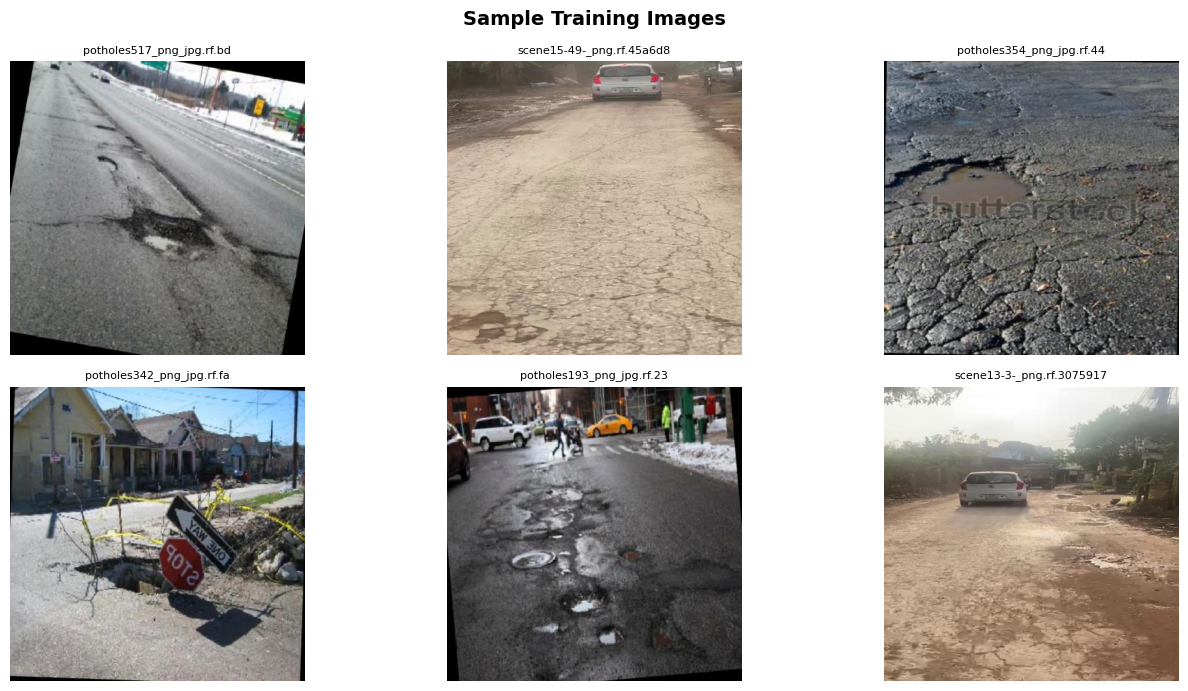

In [12]:
# Updated Cell 5
import os, matplotlib.pyplot as plt, matplotlib.image as mpimg, random

train_img_dir = "/content/Pothole-1/train/images"
val_img_dir   = "/content/Pothole-1/valid/images"

train_imgs = os.listdir(train_img_dir)
val_imgs   = os.listdir(val_img_dir)

print(f"Training images  : {len(train_imgs)}")
print(f"Validation images: {len(val_imgs)}")

# Show 6 random training images
sample = random.sample(train_imgs, min(6, len(train_imgs)))
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Sample Training Images", fontsize=14, fontweight="bold")
for ax, img_name in zip(axes.flat, sample):
    img = mpimg.imread(os.path.join(train_img_dir, img_name))
    ax.imshow(img)
    ax.set_title(img_name[:25], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## Cell 6 — Configure Training

In [13]:
# Cell 6 — Training Configuration
TRAIN_CONFIG = {
    'model'   : 'yolov8n.pt',        # Using YOLOv8 for stability
    'data'    : '/content/Pothole-1/data.yaml',  # ✅ correct path
    'epochs'  : 50,
    'batch'   : 16,
    'imgsz'   : 640,
    'patience': 15,
    'project' : '/content/runs/train',
    'name'    : 'pothole_yolov8',
    'plots'   : True,
    'save'    : True,
    'device'  : 0,
    'lr0'     : 0.01,
    'augment' : True,
    'mosaic'  : 1.0,
    'flipud'  : 0.1,
    'fliplr'  : 0.5,
}

print('Training Configuration:')
print('='*40)
for k, v in TRAIN_CONFIG.items():
    print(f'  {k:<12}: {v}')
print('='*40)

Training Configuration:
  model       : yolov8n.pt
  data        : /content/Pothole-1/data.yaml
  epochs      : 50
  batch       : 16
  imgsz       : 640
  patience    : 15
  project     : /content/runs/train
  name        : pothole_yolov8
  plots       : True
  save        : True
  device      : 0
  lr0         : 0.01
  augment     : True
  mosaic      : 1.0
  flipud      : 0.1
  fliplr      : 0.5


---
## Cell 7 — Train the Model

In [14]:
from ultralytics import YOLO

model = YOLO(TRAIN_CONFIG['model'])

print('🚀 Starting training...')
results = model.train(
    data     = TRAIN_CONFIG['data'],
    epochs   = TRAIN_CONFIG['epochs'],
    batch    = TRAIN_CONFIG['batch'],
    imgsz    = TRAIN_CONFIG['imgsz'],
    patience = TRAIN_CONFIG['patience'],
    project  = TRAIN_CONFIG['project'],
    name     = TRAIN_CONFIG['name'],
    plots    = TRAIN_CONFIG['plots'],
    save     = TRAIN_CONFIG['save'],
    device   = TRAIN_CONFIG['device'],
    lr0      = TRAIN_CONFIG['lr0'],
    augment  = TRAIN_CONFIG['augment'],
    mosaic   = TRAIN_CONFIG['mosaic'],
    flipud   = TRAIN_CONFIG['flipud'],
    fliplr   = TRAIN_CONFIG['fliplr'],
)

BEST_WEIGHTS = str(results.save_dir) + '/weights/best.pt'
print(f'\n✅ Training complete!')
print(f'📦 Best weights: {BEST_WEIGHTS}')

🚀 Starting training...
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Pothole-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pothole_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

---
## Cell 8 — Evaluate the Model

In [15]:
from ultralytics import YOLO

best_model = YOLO(BEST_WEIGHTS)
metrics = best_model.val(
    data  = '/content/Pothole-1/data.yaml',
    imgsz = 640,
    verbose = True
)

print('\n' + '='*45)
print('  Validation Results')
print('='*45)
print(f'  mAP@50      : {metrics.box.map50:.4f}  ({metrics.box.map50*100:.1f}%)')
print(f'  mAP@50-95   : {metrics.box.map:.4f}  ({metrics.box.map*100:.1f}%)')
print(f'  Precision   : {metrics.box.mp:.4f}')
print(f'  Recall      : {metrics.box.mr:.4f}')
print('='*45)
print()
print('mAP@50 Guide:')
print('  < 0.40  → Need more data or more epochs')
print('  0.40-0.60 → Decent — tune hyperparameters')
print('  0.60-0.80 → Good performance!')
print('  > 0.80  → Excellent!')

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1775.7±589.2 MB/s, size: 53.7 KB)
val: Scanning /content/Pothole-1/valid/labels.cache... 555 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 555/555 211.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 4.4it/s 7.9s
                   all        555       1449      0.773      0.671      0.771      0.452
Speed: 2.1ms preprocess, 4.2ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val

  Validation Results
  mAP@50      : 0.7706  (77.1%)
  mAP@50-95   : 0.4523  (45.2%)
  Precision   : 0.7732
  Recall      : 0.6707

mAP@50 Guide:
  < 0.40  → Need more data or more epochs
  0.40-0.60 → Decent — tune hyperparameters
  0.60-0.80 → Good performance!
  > 0.80  → E

---
## Cell 9 — Plot Training Curves

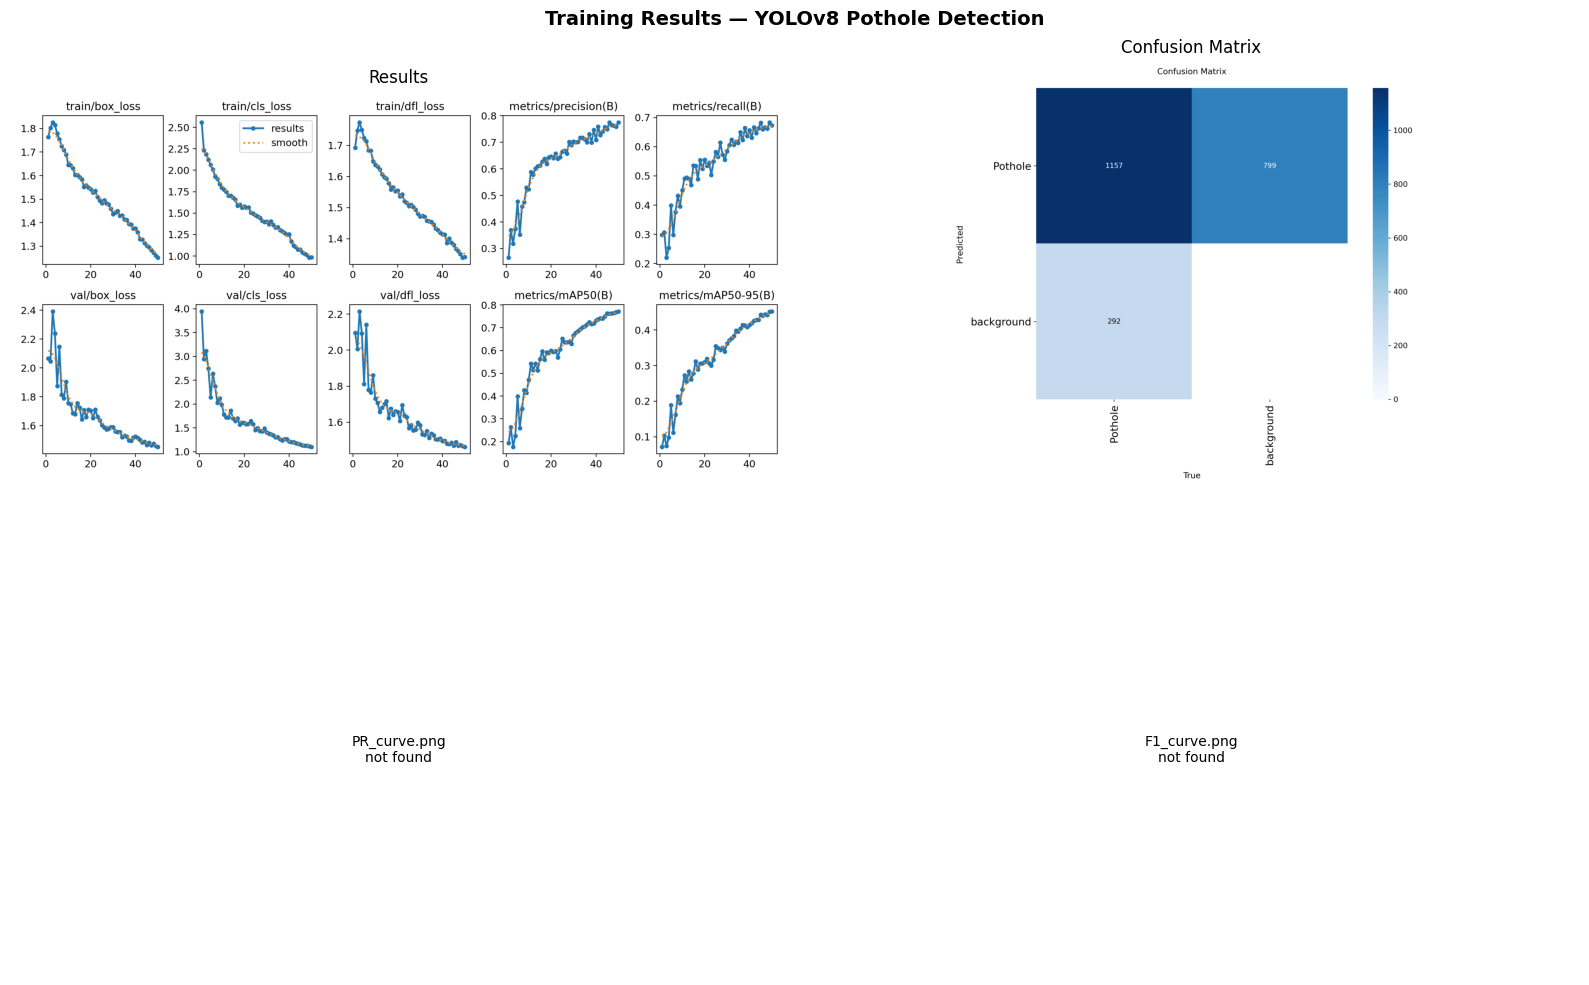

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

save_dir = str(results.save_dir)
plots_to_show = ['results.png', 'confusion_matrix.png', 'PR_curve.png', 'F1_curve.png']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training Results — YOLOv8 Pothole Detection', fontsize=14, fontweight='bold')

for ax, plot_name in zip(axes.flat, plots_to_show):
    plot_path = os.path.join(save_dir, plot_name)
    if os.path.exists(plot_path):
        img = mpimg.imread(plot_path)
        ax.imshow(img)
        ax.set_title(plot_name.replace('.png','').replace('_',' ').title())
    else:
        ax.text(0.5, 0.5, f'{plot_name}\nnot found', ha='center', va='center')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Cell 10 — Run Inference on Sample Images

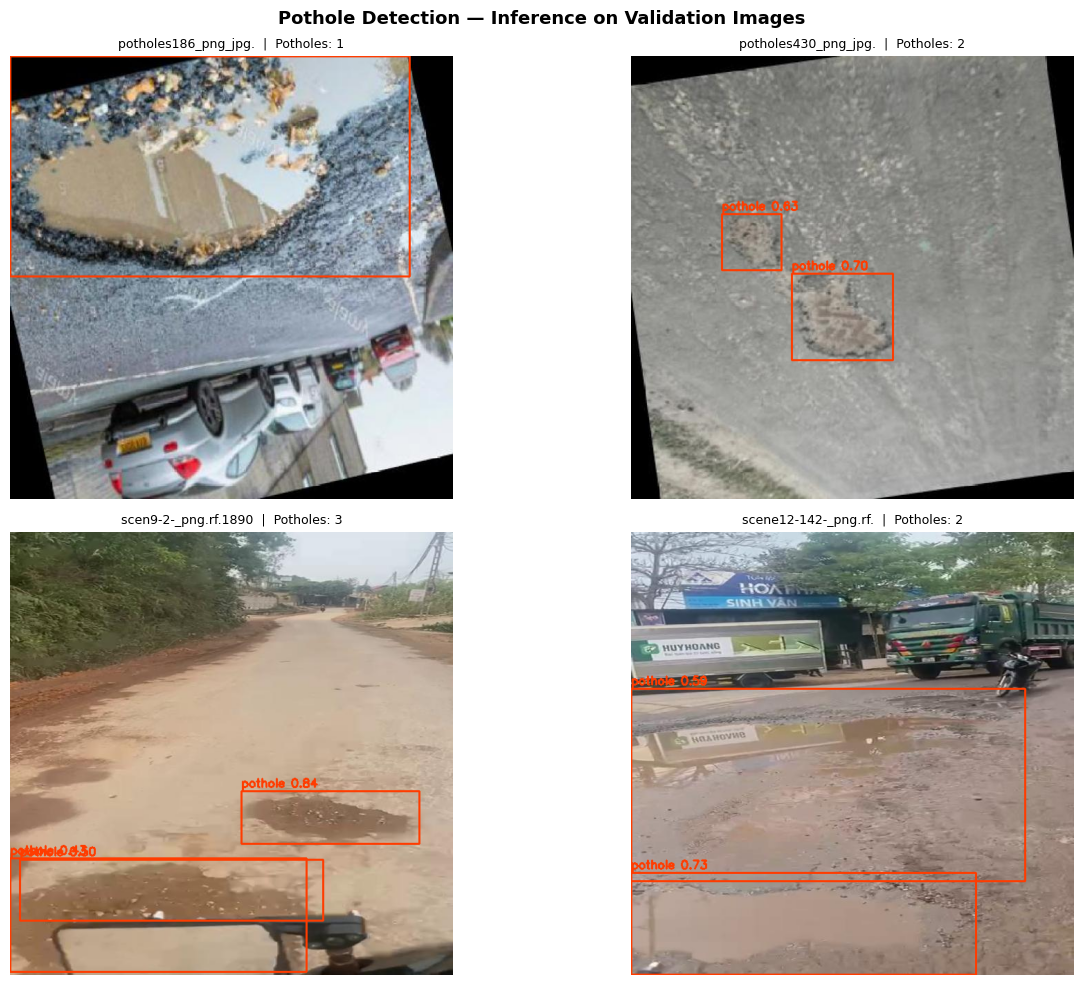

In [17]:
import os, random
import matplotlib.pyplot as plt
import cv2
import numpy as np

val_dir = '/content/Pothole-1/valid/images'   # ✅ updated path
sample_imgs = random.sample(os.listdir(val_dir), min(4, len(os.listdir(val_dir))))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pothole Detection — Inference on Validation Images', fontsize=13, fontweight='bold')

for ax, img_name in zip(axes.flat, sample_imgs):
    img_path = os.path.join(val_dir, img_name)
    pred = best_model.predict(img_path, conf=0.4, verbose=False)

    frame = cv2.imread(img_path)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    for box in pred[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 60, 0), 2)
        cv2.putText(frame, f'pothole {conf:.2f}', (x1, y1 - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 60, 0), 2)

    count = len(pred[0].boxes)
    ax.imshow(frame)
    ax.set_title(f'{img_name[:20]}  |  Potholes: {count}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Cell 11 — Save Weights to Google Drive

In [18]:
import shutil, os

save_dir = str(results.save_dir)
weights_dir = os.path.join(save_dir, 'weights')
drive_weights = '/content/drive/MyDrive/CGIP_Pothole_Detection/weights'
os.makedirs(drive_weights, exist_ok=True)

for w in ['best.pt', 'last.pt']:
    src = os.path.join(weights_dir, w)
    dst = os.path.join(drive_weights, w)
    if os.path.exists(src):
        shutil.copy(src, dst)
        size_mb = os.path.getsize(dst) / 1e6
        print(f'✅ Saved {w} → {dst}  ({size_mb:.1f} MB)')

results_png = os.path.join(save_dir, 'results.png')
if os.path.exists(results_png):
    shutil.copy(results_png, drive_weights)
    print(f'✅ Saved results.png to Drive')

print(f'\n📁 All saved to: {drive_weights}')
print('   Download best.pt → place in VS Code: models/best.pt')

✅ Saved best.pt → /content/drive/MyDrive/CGIP_Pothole_Detection/weights/best.pt  (6.2 MB)
✅ Saved last.pt → /content/drive/MyDrive/CGIP_Pothole_Detection/weights/last.pt  (6.2 MB)
✅ Saved results.png to Drive

📁 All saved to: /content/drive/MyDrive/CGIP_Pothole_Detection/weights
   Download best.pt → place in VS Code: models/best.pt


---
## Cell 12 — Download best.pt Directly (Optional)

In [19]:
from google.colab import files

best_pt_path = str(results.save_dir) + '/weights/best.pt'
files.download(best_pt_path)
print('✅ Downloading best.pt to your computer...')
print('   Place it in your VS Code project: models/best.pt')
print('   Then run:')
print('   python detect_potholes.py --source road.mp4 --model models/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloading best.pt to your computer...
   Place it in your VS Code project: models/best.pt
   Then run:
   python detect_potholes.py --source road.mp4 --model models/best.pt


---
## ✅ Next Steps

Once you have `best.pt`:

```bash
# In VS Code terminal:
python detect_potholes.py --source road.mp4 --model models/best.pt --conf 0.4
```

**Tips to improve mAP:**
- Train for more epochs (100–150)
- Use a larger model variant (`yolov12s.pt` or `yolov12m.pt`)
- Add more training images (500+ recommended)
- Lower confidence threshold if missing detections
- Raise confidence threshold if too many false positives